In [1]:
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists() and ROOT_DIR.parent.exists():
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR / "src") not in sys.path:
    sys.path.insert(0, str(ROOT_DIR / "src"))

from song_recommender.paths import DATA_DIR, BASELINE_DIR, RESNET_MODELS_DIR, CONFIGS_DIR
from song_recommender.utils import load_config
from song_recommender.training import spec_baseline
from song_recommender.models import StemLateFusionResNet18, load_resnet_model, build_song_embeddings
from song_recommender.models.loader import load_tag_cluster_map, load_valid_tags
from song_recommender.data import StemSongDataset, TrackIndexer
from song_recommender.features.tag_features import add_tag_cluster_features
from song_recommender.evaluation import (
    topk_cosine, build_cluster_relevance_vector,
    precision_at_k, recall_at_k, average_precision_at_k,
    ndcg_at_k, jaccard_similarity, dominant_cluster_accuracy_at_k,
    artist_diversity_at_k, intra_list_diversity_at_k, novelty_at_k,
    discounted_novelty_at_k, 
)

sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"device: {device}")

device: cuda


# Evaluation Metrics

We start this notebook by explaining each of the metrics that we will evaluate our models with. To start, we load the validation datset with the adjusted tag embeddings and clusters.

In [2]:
# Load config
config = load_config(CONFIGS_DIR / 'embeddings.yaml')

# Load the dataset files along with tag information
train_df = add_tag_cluster_features(pd.read_parquet(DATA_DIR / 'processed/train.parquet'), load_valid_tags(), load_tag_cluster_map())
val_df = add_tag_cluster_features(pd.read_parquet(DATA_DIR / 'processed/val.parquet'), load_valid_tags(), load_tag_cluster_map())
test_df = add_tag_cluster_features(pd.read_parquet(DATA_DIR / 'processed/test.parquet'), load_valid_tags(), load_tag_cluster_map())

#full_df = pd.concat([train_df, val_df], ignore_index = True)

test_df.sample(25)
#full_df.sample(25)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,deezer_artist,isrc,deezer_tags,deezer_year,tag_list,clean_tags,tag_set,tag_clusters,cluster_set,dominant_cluster
401,TRIXFJA128F9328DAB,Where Are You Now,Mumford & Sons,https://p.scdn.co/mp3-preview/d8f29d71f44f5955...,2FZVRvWiKPAAZktlJ7ergJ,"alternative, indie, folk, british, acoustic",Pop,2012,219853,0.383,...,Mumford & Sons,GBUM71204892,alternative,2019,"[alternative, indie, folk, british, acoustic]","[alternative, indie, folk, british, acoustic]","{indie, folk, alternative, british, acoustic}","[19, 18, 17, 20, 17]","{17, 18, 19, 20}",17.0
583,TRXNGOC128EF34A4F2,I'm Crying,The Animals,https://p.scdn.co/mp3-preview/7096a780d6c4b12d...,05do6Jl7DrtjXLVFH1kLGU,"rock, classic_rock, punk, punk_rock, blues, ps...",NaN,2014,169346,0.548,...,The Animals,USA176460020,pop,2008,"[rock, classic_rock, punk, punk_rock, blues, p...","[classic_rock, punk, punk_rock, blues, psyched...","{oldies, psychedelic, classic_rock, blues_rock...","[16, 15, 15, 16, 5, 16, 13, 17, 13, 16]","{5, 13, 15, 16, 17}",16.0
190,TRWMXEH128F9317169,And Then Patterns,Four Tet,https://p.scdn.co/mp3-preview/cac986e7aa22564b...,08FC4kEaZaM5HmEaAXvuTx,"electronic, ambient, experimental, instrumenta...",Electronic,2005,284466,0.816,...,Four Tet,GBCEL0400358,electro,2005,"[electronic, ambient, experimental, instrument...","[electronic, ambient, experimental, instrument...","{electronic, ambient, downtempo, chill, instru...","[11, 7, 5, 7, 12, 12, 12, 12, 12]","{11, 12, 5, 7}",12.0
824,TRUKOEM128F425DA94,Year 2000 Non-Compliant Cardia,Mogwai,https://p.scdn.co/mp3-preview/120d11b909ae44d0...,0dNEJ32R6EhtN8PZaOAAvy,"instrumental, post_rock",NaN,1999,205640,0.503,...,Mogwai,GBCGR9960003,"alternative, rock",2015,"[instrumental, post_rock]","[instrumental, post_rock]","{instrumental, post_rock}","[7, 5]","{5, 7}",7.0
834,TRZYQBX128E0780E1B,Bijou,Queen,https://p.scdn.co/mp3-preview/c6201281eb249426...,0g7AkY1T1lt9kYuBUPOv1I,"rock, classic_rock, hard_rock, instrumental, g...",Rock,1991,216866,0.229,...,Queen,GBUM71106220,rock,2025,"[rock, classic_rock, hard_rock, instrumental, ...","[classic_rock, hard_rock, instrumental, guitar]","{instrumental, guitar, classic_rock, hard_rock}","[16, 14, 7, 16]","{16, 14, 7}",16.0
592,TRDGJFN128F9300AB0,Of Dust And Nations,Thrice,https://p.scdn.co/mp3-preview/b9f3769eb91b7da2...,0El8nPigJiFVU12yj4QrlZ,"rock, punk, progressive_rock, emo, post_hardco...",Rock,2012,277976,0.111,...,Thrice,USUM70504403,rock,2005,"[rock, punk, progressive_rock, emo, post_hardc...","[punk, progressive_rock, emo, post_hardcore, s...","{post_hardcore, emo, screamo, punk, progressiv...","[15, 5, 13, 13, 13]","{13, 5, 15}",13.0
812,TRUZFBD128F933D5E2,Miserlou,Dick Dale,https://p.scdn.co/mp3-preview/610069824525109e...,01wdwhsRhThaEWyVY9Nc5C,"rock, instrumental, 60s, guitar, surf_rock",NaN,2014,136045,0.296,...,Dick Dale & His Del-Tones,US3JR0910015,rock,2009,"[rock, instrumental, 60s, guitar]","[instrumental, 60s, guitar]","{instrumental, guitar, 60s}","[7, 16, 16]","{16, 7}",16.0
103,TRCRCNE12903CE2562,Wild Night,Van Morrison,https://p.scdn.co/mp3-preview/9b997d7d2c6ee763...,1A7hIo1C8jacIQ5ZiCjc8g,"rock, classic_rock, folk, singer_songwriter, b...",NaN,2015,213600,0.568,...,Van Morrison,USQX91501805,rock,2015,"[rock, classic_rock, folk, singer_songwriter, ...","[classic_rock, folk, singer_songwriter, blues,...","{folk, classic_rock, blues, 70s, singer_songwr...","[16, 17, 17, 16, 16]","{16, 17}",16.0
1045,TRMEYJP12903CC3357,Meaning,Gavin DeGraw,https://p.scdn.co/mp3-preview/ddd830c9a05518c9...,23BYApybgXduXc3ldk420g,"rock, pop, singer_songwriter, acoustic, piano,...",NaN,2003,215253,0.435,...,Gavin Degraw,USJAY0400263,pop,2004,"[rock, pop, singer_songwriter, acoustic, piano...","[pop, singer_songwriter, acoustic, piano, male...","{mellow, singer_songwriter, male_vocalists, po...","[10, 17, 17, 6, 17, 17, 17, 17]","{17, 10, 6}",17.0
1129,TROLJKM128E07911F2,Hopelessly Devo

## Relevance

Before defining each metric, we need to define what it means for a recommended track to be *relevant* to the query track. We will say that the recommended track is relevant to the query track if

1. the query and the recommendation have the same `dominant_cluster`, or
2. they have significant cluster overlap.

We say that the two tracks have *significant cluster overlap* if the [Jaccard similarity index](https://en.wikipedia.org/wiki/Jaccard_index) is greater than or equal to a chosen threshold, $\tau$. More precisely, if $Q$ is the **set** of clusters for the query and $R$ is the **set** of clusters for the recommended track, we say that the overlap is significant if 

$$J(Q, R) = \frac{\lvert Q\cap R \rvert}{\lvert Q\cup R \rvert} \ge \tau.$$

For this notebook, we chose $\tau = 0.25$.

**Remark:** recall that `dominant_cluster` is determined by the mode of `tag_clusters`. If `tag_clusters` is multimodal, then the first appearing cluster in the list of multimodal clusters is selected. So while repetition of clusters in `tag_clusters` is not represented in the Jaccard index, it is represented in `dominant_cluster`.

## Metric Functions

For each query, we assigned a relevance vector $\mathbf{r} = \left[r_1, r_2, \ldots, r_k\right]^T$ using the tag embeddings and clusters, where $r_i = 1$ if the $i$-th recommended track is relevant to the query track and 0 otherwise for each $1 \le i \le k$.

We consider the following metrics for a query and its relevance vector:

1. Precision@k: number of relevant neighbors out of $k$
    - Measures recommendation quality, i.e., accuracy of relevant retrieval
    - Not rank aware
2. Recall@k: number of relevant neighbors out of total number of relevant items in dataset
    - Measures models ability to retrieve all relevant tracks
    - Will be very small if there are many "relevant" tracks, especially for small $k$
3. AP@k (Average Precision at k): Average of $r_i \cdot $ precision@i for $i = 1,\ldots, k$
    - Measures ranking quality
    - Penalizes relevant tracks appearing later in $k$-neighbors
4. nDCG@k ([Normalized Discounted Cumulative Gain](https://www.google.com/url?sa=i&source=web&rct=j&url=https://en.wikipedia.org/wiki/Discounted_cumulative_gain) at k): DCG@k over IDCG@k (Ideal DCG)
    * DCG@k is the sum of relevance results, discounted logarithmically by their position in $k$-neighbors:

    $$\text{DCG}@k = \sum_{i = 1}^k \frac{r_i}{\log_2(i+1)}$$
    * IDCG@k is the maximum possible DCG if $k$-neighbors were sorted by relevance, i.e., if $0 \le t \le k$ and $t$ of the $k$-neighbors are relevant, then $r_i > 0$ for all $i \le t$ and $$\text{IDCG}@k = \sum_{i = 1}^t \frac{r_i}{\log_2(i+1)}$$
    - Measures ranking quality
    - Rewards highly relevant tracks appearing earlier in $k$-neigbors
    - Grades relevance, e.g., highly relevant vs. partially relevant
    - Not as useful if relevance has a binary grading
    - Normalized for comparision across queries
5. Tag Jaccard Similarity: Average of tag Jaccard similarity for query against each $k$-neighbor
    - Measures if $k$-neighbors share tags
    - Not using relevancy vectors
    - Not used to compute relevancy
6. Cluster Jaccard Similarity: Average of cluster Jaccard similarity for query against each $k$-neighbor
    - Measures if $k$-neighbors share clusters
    - Not using relevancy vectors
    - Used to compute relevancy
7. Dominant Cluster Accuracy@k: number of neighbors whose dominant cluster matches query out of $k$

In [6]:
def evaluate_embeddings(
    query_emb, db_emb, query_df, db_df,
    k_list=(5, 10, 20, 50), overlap_threshold=0.25, self_retrieval=False,
):
    """
    Evaluate embedding retrieval quality using tag-cluster metrics.

    Args:
        query_emb:        (N_q, D) normalized embeddings for queries
        db_emb:           (N_db, D) normalized embeddings for database
        query_df/db_df:   DataFrames with cluster_set, dominant_cluster, tag_set columns
        k_list:           k values to evaluate
        overlap_threshold: Jaccard threshold for cluster overlap relevance
        self_retrieval:   if True, exclude index i from db (when query_emb is db_emb)

    Returns:
        dict {k: {metric_name: float}}
    """
    artist_counts   = db_df["artist"].value_counts().to_dict()
    db_cluster_sets = db_df["cluster_set"].values
    db_dom_clusters = db_df["dominant_cluster"].values
    db_tag_sets     = db_df["tag_set"].values
    db_artists      = db_df["artist"].values
    q_cluster_sets  = query_df["cluster_set"].values
    q_dom_clusters  = query_df["dominant_cluster"].values
    q_tag_sets      = query_df["tag_set"].values

    query_ids = query_df["spotify_id"].tolist()
    db_id_to_idx = {sid: i for i, sid in enumerate(db_df["spotify_id"].tolist())}

    max_k = max(k_list)

    accumulators = {k: {
        "prec": [], "rec": [], "ap": [], "ndcg": [],
        "tag_j": [], "clus_j": [], "dom_acc": [],
        "artist_div": [], "ild": [], "novelty": [], "disc_novelty": [],
    } for k in k_list}

    for i in range(len(query_emb)):
        exclude = db_id_to_idx.get(query_ids[i]) if self_retrieval else None

        # Retrieve top-max_k once, slice for each k
        top_idx, _ = topk_cosine(db_emb, query_emb[i], max_k, exclude_idx=exclude)

        full_rel = build_cluster_relevance_vector(
            q_cluster_sets[i], db_cluster_sets,
            q_dom_clusters[i], db_dom_clusters,
            overlap_threshold,
        )
        total_relevant = max(0, int(np.sum(full_rel)) - (1 if self_retrieval else 0))

        for k in k_list:
            idx = top_idx[:k]

            relevance = build_cluster_relevance_vector(
                q_cluster_sets[i], db_cluster_sets[idx],
                q_dom_clusters[i], db_dom_clusters[idx],
                overlap_threshold,
            )
            neighbor_artists = db_artists[idx]
            neighbor_embs    = db_emb[idx]

            acc = accumulators[k]
            acc["prec"].append(precision_at_k(relevance))
            acc["rec"].append(recall_at_k(relevance, total_relevant))
            acc["ap"].append(average_precision_at_k(relevance))
            acc["ndcg"].append(ndcg_at_k(relevance))
            acc["dom_acc"].append(dominant_cluster_accuracy_at_k(q_dom_clusters[i], db_dom_clusters[idx]))
            acc["tag_j"].append(np.mean([jaccard_similarity(q_tag_sets[i], t) for t in db_tag_sets[idx]]))
            acc["clus_j"].append(np.mean([jaccard_similarity(q_cluster_sets[i], c) for c in db_cluster_sets[idx]]))
            acc["artist_div"].append(artist_diversity_at_k(neighbor_artists))
            acc["ild"].append(intra_list_diversity_at_k(neighbor_embs))
            acc["novelty"].append(novelty_at_k(neighbor_artists, artist_counts))
            acc["disc_novelty"].append(discounted_novelty_at_k(neighbor_artists, artist_counts))

    return {
        k: {
            "precision@k":            np.mean(acc["prec"]),
            "recall@k":               np.mean(acc["rec"]),
            "map@k":                  np.mean(acc["ap"]),
            "ndcg@k":                 np.mean(acc["ndcg"]),
            "tag_jaccard":            np.mean(acc["tag_j"]),
            "cluster_jaccard":        np.mean(acc["clus_j"]),
            "dominant_cluster_acc@k": np.mean(acc["dom_acc"]),
            "artist_diversity@k":     np.mean(acc["artist_div"]),
            "intra_list_diversity@k": np.mean(acc["ild"]),
            "novelty@k":              np.mean(acc["novelty"]),
            "discounted_novelty@k":   np.mean(acc["disc_novelty"]),
        }
        for k, acc in accumulators.items()
    }

# Embedding Computer

In [ ]:
# Baseline Model Information
baseline_emb = spec_baseline.build_embeddings(val_df, config)

# Sanity Checking
print("baseline:", baseline_emb.shape)

# Load Train + Validation Data
loader = DataLoader(StemSongDataset(val_df, image_size=224), batch_size=32, shuffle=False, num_workers=0)

# Resnet Notebook04 Information
model  = load_resnet_model( RESNET_MODELS_DIR / "04_Resnet18_contrastive_tags/checkpoint.pt", device)
out    = build_song_embeddings(model, loader, device)
resnet04_emb = out["song_embeddings"]

print("resnet04:", resnet04_emb.shape)

# Resnet Notebook05 Information
model  = load_resnet_model( RESNET_MODELS_DIR / "05_Resnet18_contrastive_tags_infonce/checkpoint.pt", device)
out    = build_song_embeddings(model, loader, device)
resnet05_emb = out["song_embeddings"]

print("resnet05:", resnet05_emb.shape)

# Resnet Notebook04_BEEG Information
model  = load_resnet_model( RESNET_MODELS_DIR / "04a_Resnet18_contrastive_tags_BEEG/checkpoint.pt", device)
out    = build_song_embeddings(model, loader, device)
resnet04a_emb = out["song_embeddings"]

print("resnet04a:", resnet04a_emb.shape)

# Resnet Notebook06 Information
model  = load_resnet_model( RESNET_MODELS_DIR / "06_Resnet18_contrastive_tags_audio_grounded_infonce/checkpoint.pt", device)
out    = build_song_embeddings(model, loader, device)
resnet06_emb = out["song_embeddings"]

print("resnet06:", resnet06_emb.shape)

# Resnet Notebook07 Information
model  = load_resnet_model( RESNET_MODELS_DIR / "07_Resnet18_audio_centric_blended_teacher/checkpoint.pt", device)
out    = build_song_embeddings(model, loader, device)
resnet07_emb = out["song_embeddings"]

print("resnet06:", resnet07_emb.shape)

# Future Resnet Models...

# Sanity Checking
print("baseline:", baseline_emb.shape)
print("resnet04:", resnet04_emb.shape)
print("resnet05:", resnet05_emb.shape)
print("resnet04a:", resnet04a_emb.shape)
print("resnet06:", resnet06_emb.shape)

embedding 1/1447
embedding 201/1447
embedding 401/1447
embedding 601/1447
embedding 801/1447
embedding 1001/1447
embedding 1201/1447
embedding 1401/1447
baseline: (1447, 5120)
resnet04: (1447, 64)
resnet05: (1447, 64)
resnet04a: (1447, 64)
resnet06: (1447, 64)
resnet06: (1447, 64)
baseline: (1447, 5120)
resnet04: (1447, 64)
resnet05: (1447, 64)
resnet04a: (1447, 64)
resnet06: (1447, 64)


In [ ]:
np.savez(
    DATA_DIR / "processed" / "model_runs" / "all_val_embeddings.npz",
    baseline=baseline_emb,
    resnet04=resnet04_emb,
    resnet05=resnet05_emb,
    resnet04a=resnet04a_emb,
    resnet06=resnet06_emb,
    resnet07=resnet07_emb,
)

## Test Embedding Computer

In [4]:
# Baseline Model Information
test_baseline_emb = spec_baseline.build_embeddings(test_df, config)

# Sanity Checking
print("baseline:", test_baseline_emb.shape)

# Load Train + Validation Data
loader = DataLoader(StemSongDataset(test_df, image_size=224), batch_size=32, shuffle=False, num_workers=0)

# Resnet Notebook04 Information
model  = load_resnet_model( RESNET_MODELS_DIR / "04_Resnet18_contrastive_tags/checkpoint.pt", device)
out    = build_song_embeddings(model, loader, device)
test_resnet04_emb = out["song_embeddings"]

print("resnet04:", test_resnet04_emb.shape)

embedding 1/1690
embedding 201/1690
embedding 401/1690
embedding 601/1690
embedding 801/1690
embedding 1001/1690
embedding 1201/1690
embedding 1401/1690
embedding 1601/1690
baseline: (1690, 5120)
resnet04: (1690, 64)


In [5]:
np.savez(
    DATA_DIR / "processed" / "model_runs" / "test_embeddings.npz",
    baseline=test_baseline_emb,
    resnet04=test_resnet04_emb,
)

In [11]:
data = data = np.load(DATA_DIR / "processed" / "model_runs" / "all_train_embeddings.npz")

tbaseline_emb  = data["baseline"]
tresnet04_emb  = data["resnet04"]

print("baseline:",  tbaseline_emb.shape)
print("resnet04:",  tresnet04_emb.shape)

baseline: (8102, 5120)
resnet04: (8102, 64)


## Embedding Loading

In [4]:
data = data = np.load(DATA_DIR / "processed" / "model_runs" / "all_train_embeddings.npz")

tbaseline_emb  = data["baseline"]
tresnet04_emb  = data["resnet04"]
tresnet05_emb  = data["resnet05"]
tresnet06_emb  = data["resnet06"]
tresnet07_emb  = data["resnet07"]

print("baseline:",  tbaseline_emb.shape)
print("resnet04:",  tresnet04_emb.shape)
print("resnet05:",  tresnet05_emb.shape)
print("resnet06:",  tresnet06_emb.shape)
print("resnet07:",  tresnet06_emb.shape)

baseline: (8102, 5120)
resnet04: (8102, 64)
resnet05: (8102, 64)
resnet06: (8102, 64)
resnet07: (8102, 64)


In [5]:
data = np.load(DATA_DIR / "processed" / "model_runs" / "all_val_embeddings.npz")

vbaseline_emb  = data["baseline"]
vresnet04_emb  = data["resnet04"]
vresnet05_emb  = data["resnet05"]
vresnet06_emb  = data["resnet06"]
vresnet07_emb  = data["resnet07"]

print("baseline:",  vbaseline_emb.shape)
print("resnet04:",  vresnet04_emb.shape)
print("resnet05:",  vresnet05_emb.shape)
print("resnet06:",  vresnet06_emb.shape)
print("resnet07:",  vresnet06_emb.shape)

baseline: (1447, 5120)
resnet04: (1447, 64)
resnet05: (1447, 64)
resnet06: (1447, 64)
resnet07: (1447, 64)


## Metric Evaluation Computations

In [6]:
k_list = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

models = {
    "Baseline":               (tbaseline_emb,  vbaseline_emb),
    "ResNet04 (Contrastive)": (tresnet04_emb,  vresnet04_emb),
    "ResNet05 (InfoNCE)":     (tresnet05_emb,  vresnet05_emb),
    "ResNet06":               (tresnet06_emb,  vresnet06_emb),
    "ResNet07":               (tresnet07_emb,  vresnet07_emb),
}

all_results = {}
for name, (train_emb, val_emb) in models.items():
    print(f"evaluating {name}...")
    all_results[name] = evaluate_embeddings(
        query_emb=val_emb,
        db_emb=train_emb,
        query_df=val_df,
        db_df=train_df,
        k_list=k_list, 
        overlap_threshold=0.25, 
        self_retrieval=False,
    )
print("done.")

evaluating Baseline...
evaluating ResNet04 (Contrastive)...
evaluating ResNet05 (InfoNCE)...
evaluating ResNet06...
evaluating ResNet07...
done.


In [7]:
k = 1
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.4153,0.0003,0.4153,0.4153,0.1345,0.2243,0.2225,1.0,0.0,10.2716,10.2716
ResNet04 (Contrastive),0.7236,0.0005,0.7236,0.7236,0.2275,0.3681,0.4091,1.0,0.0,10.5785,10.5785
ResNet05 (InfoNCE),0.6849,0.0005,0.6849,0.6849,0.2260,0.3565,0.3912,1.0,0.0,10.4265,10.4265
ResNet06,0.6317,0.0005,0.6317,0.6317,0.2219,0.3428,0.3614,1.0,0.0,10.4910,10.4910
ResNet07,0.5556,0.0004,0.5556,0.5556,0.2084,0.3091,0.3359,1.0,0.0,10.3800,10.3800


In [8]:
k = 5
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.4008,0.0014,0.5448,0.6289,0.1267,0.2132,0.2164,0.9722,0.0292,10.2757,10.2761
ResNet04 (Contrastive),0.7201,0.0026,0.7798,0.8226,0.2290,0.3712,0.4048,0.9063,0.0352,10.4729,10.4956
ResNet05 (InfoNCE),0.6731,0.0024,0.7475,0.7958,0.2226,0.3546,0.3902,0.9292,0.0314,10.4590,10.4497
ResNet06,0.6346,0.0023,0.7181,0.7756,0.2119,0.3361,0.3649,0.9446,0.0215,10.4541,10.4610
ResNet07,0.5348,0.0019,0.6550,0.7273,0.1953,0.2976,0.3135,0.9569,0.0341,10.3513,10.3555


In [9]:
k = 10
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3853,0.0028,0.5180,0.6537,0.1182,0.2037,0.2058,0.9528,0.0308,10.2927,10.2876
ResNet04 (Contrastive),0.7205,0.0053,0.7677,0.8333,0.2305,0.3729,0.4089,0.8462,0.0397,10.4660,10.4831
ResNet05 (InfoNCE),0.6725,0.0049,0.7300,0.8079,0.2197,0.3541,0.3892,0.8815,0.0351,10.4619,10.4547
ResNet06,0.6350,0.0046,0.7010,0.7908,0.2105,0.3361,0.3660,0.9069,0.0241,10.4502,10.4561
ResNet07,0.5190,0.0037,0.6250,0.7425,0.1880,0.2895,0.2985,0.9299,0.0373,10.3550,10.3571


In [10]:
k = 20
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3713,0.0053,0.4737,0.6653,0.1103,0.1940,0.1966,0.9309,0.0326,10.3122,10.3031
ResNet04 (Contrastive),0.7198,0.0105,0.7551,0.8426,0.2317,0.3732,0.4123,0.7810,0.0451,10.4509,10.4665
ResNet05 (InfoNCE),0.6731,0.0098,0.7126,0.8175,0.2180,0.3544,0.3859,0.8241,0.0398,10.4659,10.4598
ResNet06,0.6293,0.0091,0.6792,0.8010,0.2054,0.3324,0.3602,0.8515,0.0275,10.4471,10.4513
ResNet07,0.5128,0.0074,0.5875,0.7497,0.1819,0.2841,0.2936,0.8907,0.0410,10.3555,10.3565


In [11]:
k = 50
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3540,0.0127,0.4211,0.6794,0.1009,0.1836,0.1841,0.8769,0.0355,10.3243,10.3158
ResNet04 (Contrastive),0.7151,0.0260,0.7397,0.8540,0.2300,0.3720,0.4122,0.6781,0.0549,10.4472,10.4564
ResNet05 (InfoNCE),0.6676,0.0241,0.6944,0.8312,0.2150,0.3515,0.3834,0.7276,0.0478,10.4581,10.4564
ResNet06,0.6202,0.0224,0.6534,0.8139,0.1990,0.3269,0.3535,0.7634,0.0333,10.4487,10.4506
ResNet07,0.5002,0.0179,0.5480,0.7623,0.1717,0.2727,0.2809,0.8212,0.0472,10.3550,10.3554


In [13]:
import matplotlib.pyplot as plt

def plot_metric_vs_k(all_results, metric, k_list, figsize=(10, 5)):
    """
    Plot a single metric across k values for all models.

    Args:
        all_results: dict {model_name: {k: {metric: value}}}
        metric:      metric name string (e.g. "precision@k", "ndcg@k")
        k_list:      list of k values evaluated
        figsize:     figure size tuple
    """
    fig, ax = plt.subplots(figsize=figsize)

    for model_name, results in all_results.items():
        scores = [results[k][metric] for k in k_list]
        ax.plot(k_list, scores, marker="o", label=model_name)

    ax.set_xlabel("k")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs k")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

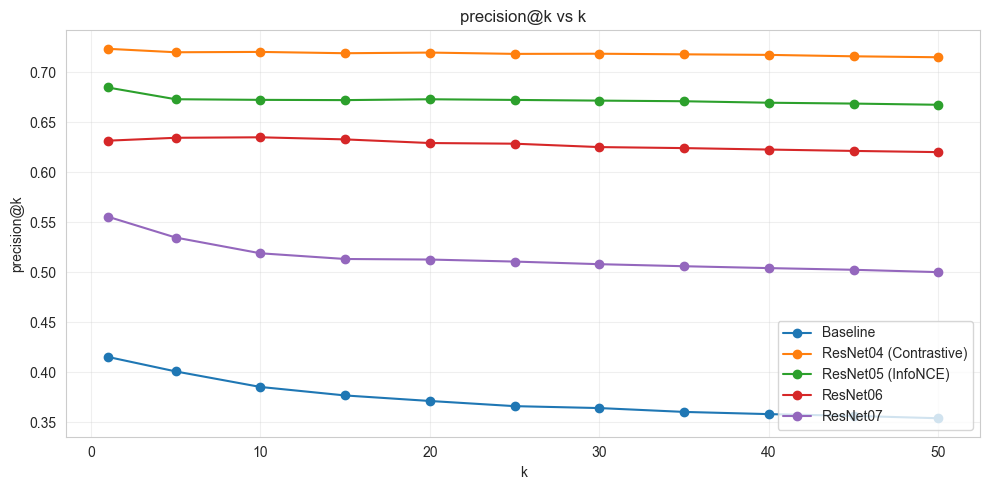

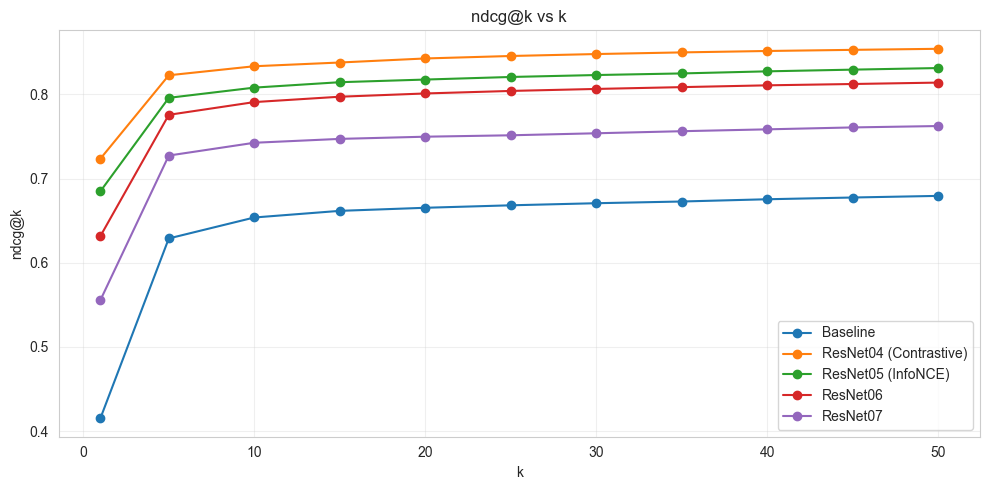

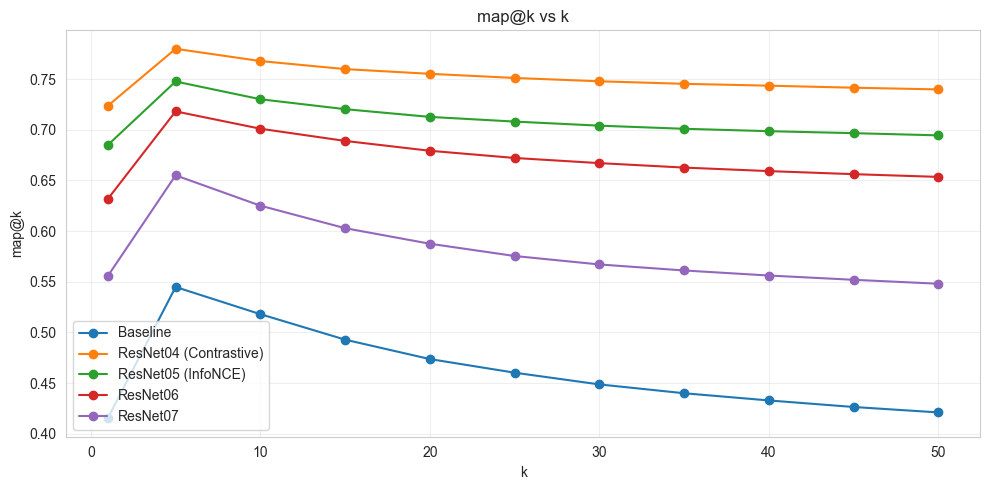

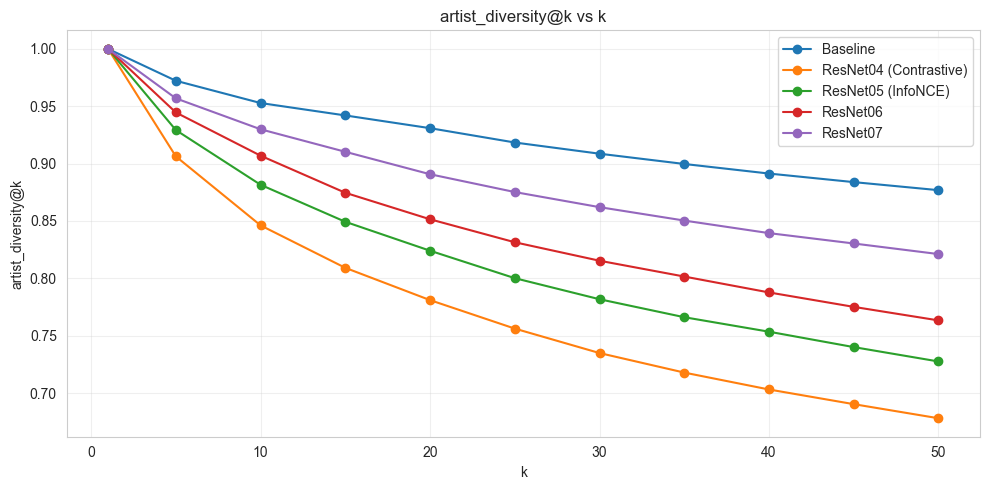

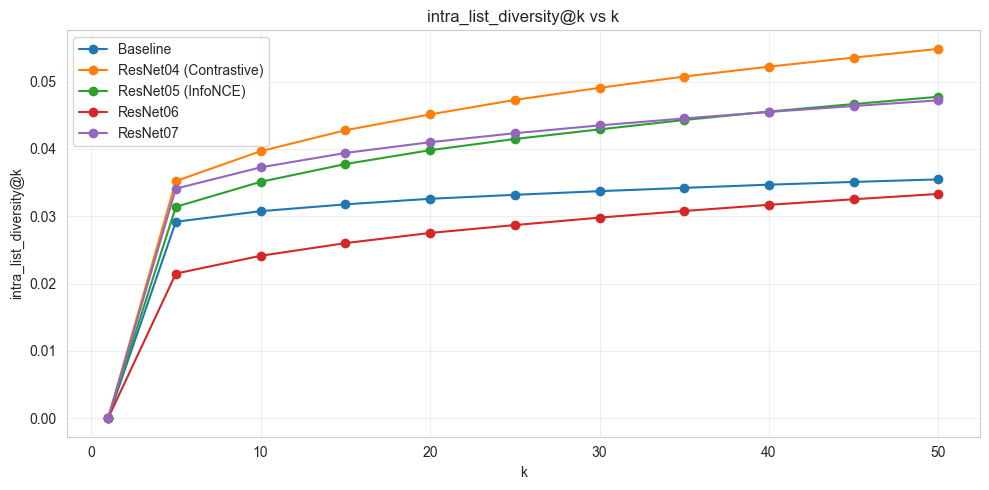

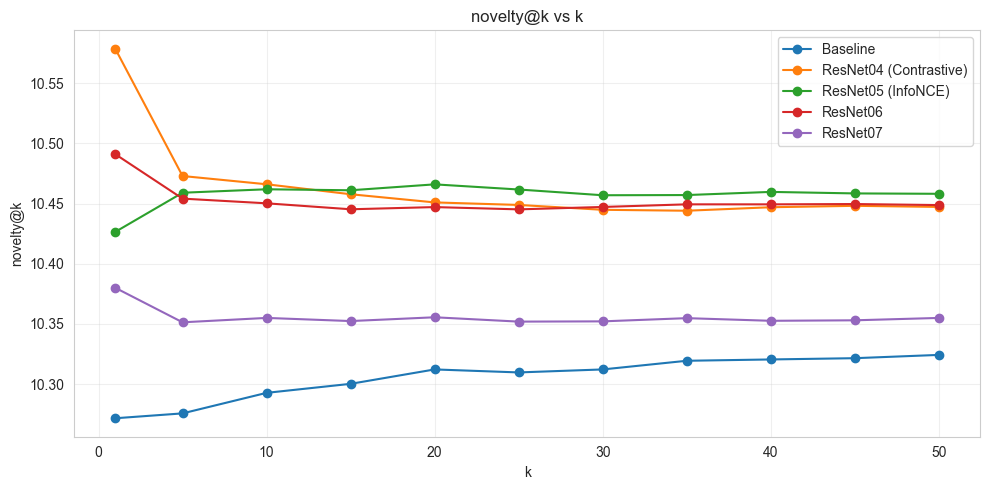

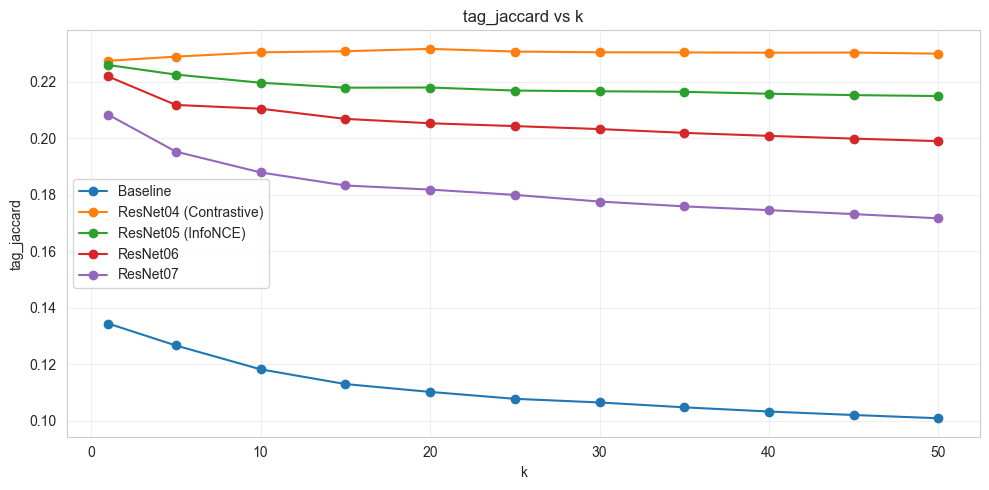

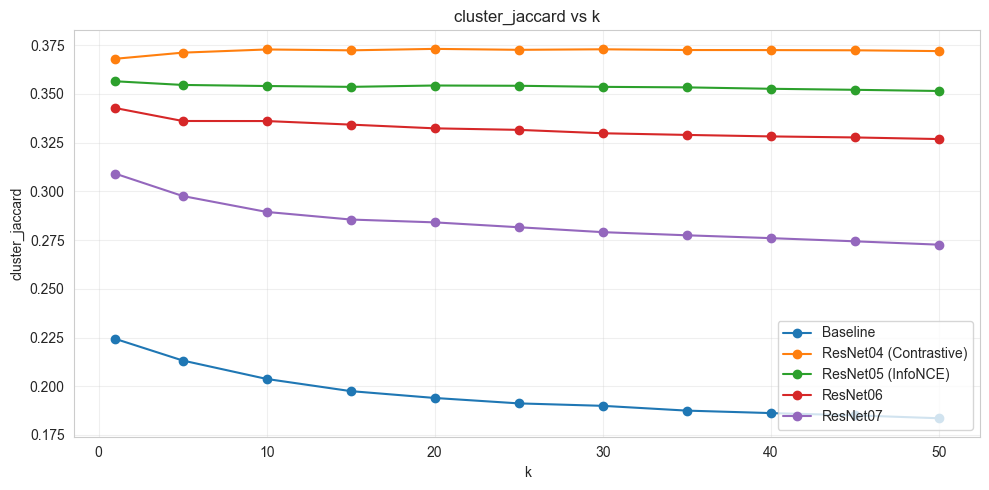

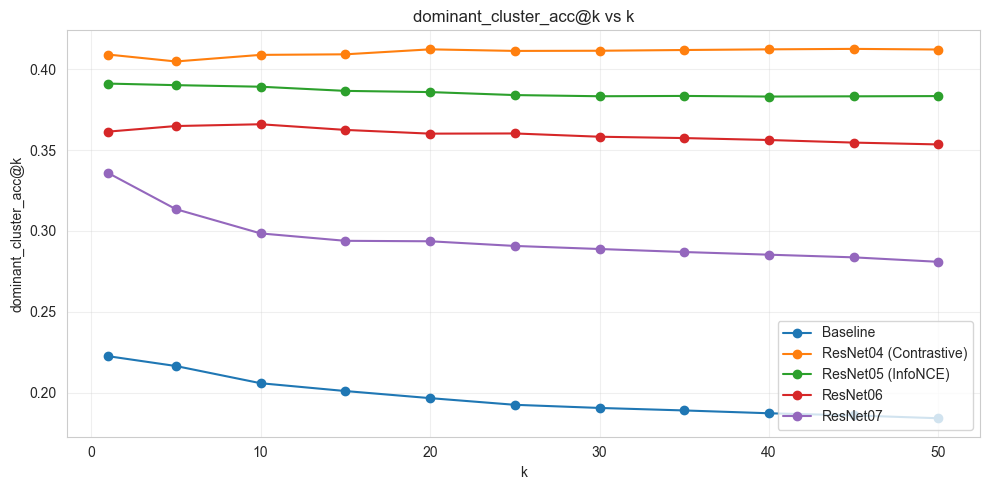

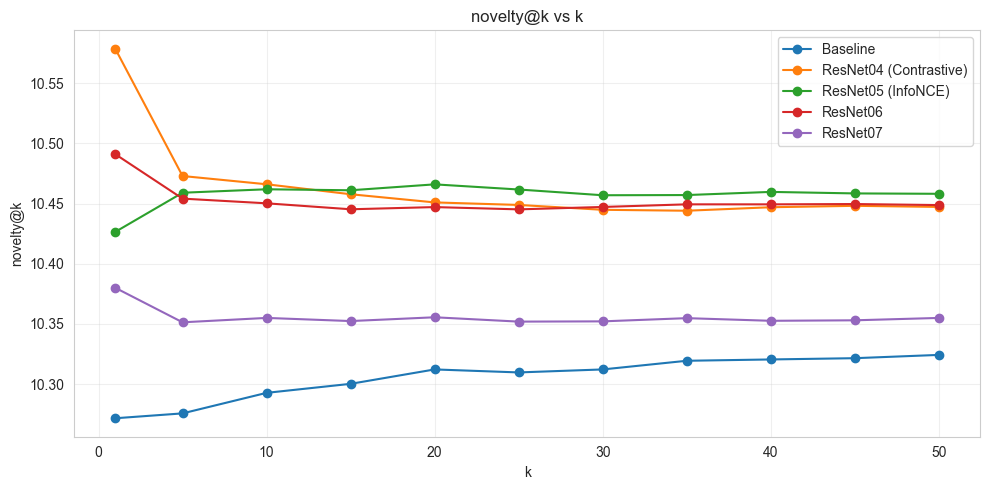

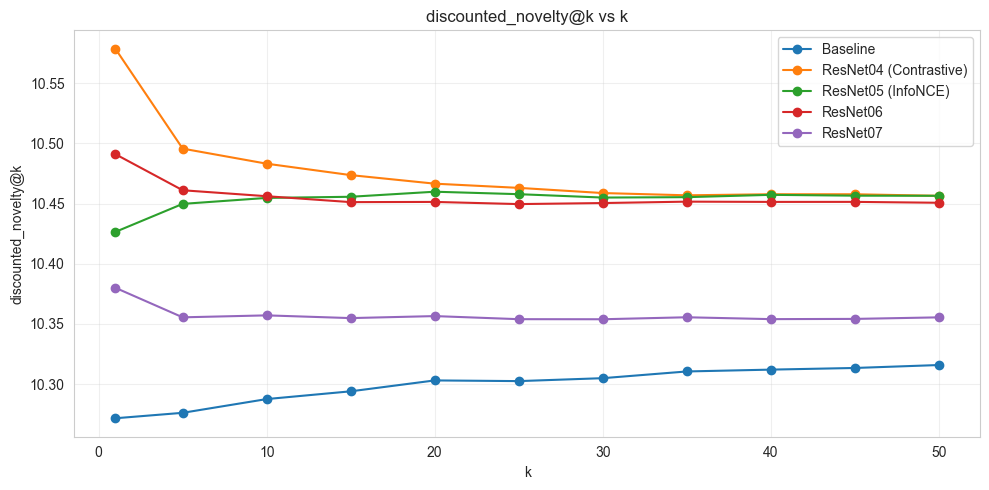

In [16]:
plot_metric_vs_k(all_results, "precision@k",            k_list)
plot_metric_vs_k(all_results, "ndcg@k",                 k_list)
plot_metric_vs_k(all_results, "map@k",                  k_list)
plot_metric_vs_k(all_results, "artist_diversity@k",     k_list)
plot_metric_vs_k(all_results, "intra_list_diversity@k", k_list)
plot_metric_vs_k(all_results, "novelty@k",              k_list)
plot_metric_vs_k(all_results, "tag_jaccard",            k_list)
plot_metric_vs_k(all_results, "cluster_jaccard",            k_list)
plot_metric_vs_k(all_results, "dominant_cluster_acc@k",            k_list)
plot_metric_vs_k(all_results, "novelty@k",              k_list)
plot_metric_vs_k(all_results, "discounted_novelty@k",            k_list)

## Test Set Metrics on Baseline and Resnet04

In [12]:
k_list = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

models = {
    "Baseline":               (tbaseline_emb,  test_baseline_emb),
    "ResNet04":               (tresnet04_emb,  test_resnet04_emb),
}

all_results = {}
for name, (train_emb, test_emb) in models.items():
    print(f"evaluating {name}...")
    all_results[name] = evaluate_embeddings(
        query_emb=test_emb,
        db_emb=train_emb,
        query_df=test_df,
        db_df=train_df,
        k_list=k_list, 
        overlap_threshold=0.25, 
        self_retrieval=False,
    )
print("done.")

evaluating Baseline...
evaluating ResNet04...
done.


In [13]:
k = 1
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3970,0.0003,0.3970,0.3970,0.1241,0.2101,0.2101,1.0,0.0,10.3524,10.3524
ResNet04,0.7041,0.0005,0.7041,0.7041,0.2148,0.3476,0.3822,1.0,0.0,10.4583,10.4583


In [14]:
k = 5
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3833,0.0014,0.5265,0.6107,0.1099,0.1973,0.1963,0.9756,0.0293,10.3403,10.3397
ResNet04,0.7018,0.0025,0.7615,0.8036,0.2165,0.3555,0.3846,0.9082,0.0368,10.4776,10.4732


In [15]:
k = 10
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3675,0.0026,0.5002,0.6376,0.1046,0.1901,0.1864,0.9569,0.0307,10.342,10.3408
ResNet04,0.7005,0.0050,0.7515,0.8173,0.2173,0.3564,0.3837,0.8527,0.0414,10.480,10.4767


In [16]:
k = 20
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3602,0.0051,0.4582,0.6537,0.1011,0.1854,0.180,0.9300,0.0325,10.3557,10.3509
ResNet04,0.6994,0.0101,0.7359,0.8256,0.2162,0.3573,0.386,0.7852,0.0471,10.4797,10.4779


In [17]:
k = 50
display(pd.DataFrame({name: res[k] for name, res in all_results.items()}).T.round(4))

,precision@k,recall@k,map@k,ndcg@k,tag_jaccard,cluster_jaccard,dominant_cluster_acc@k,artist_diversity@k,intra_list_diversity@k,novelty@k,discounted_novelty@k
Baseline,0.3450,0.0123,0.4072,0.6710,0.0936,0.1759,0.1704,0.8805,0.0352,10.3600,10.3562
ResNet04,0.6959,0.0250,0.7202,0.8388,0.2144,0.3570,0.3866,0.6860,0.0567,10.4757,10.4756


In [18]:
import matplotlib.pyplot as plt

def plot_metric_vs_k(all_results, metric, k_list, figsize=(10, 5)):
    """
    Plot a single metric across k values for all models.

    Args:
        all_results: dict {model_name: {k: {metric: value}}}
        metric:      metric name string (e.g. "precision@k", "ndcg@k")
        k_list:      list of k values evaluated
        figsize:     figure size tuple
    """
    fig, ax = plt.subplots(figsize=figsize)

    for model_name, results in all_results.items():
        scores = [results[k][metric] for k in k_list]
        ax.plot(k_list, scores, marker="o", label=model_name)

    ax.set_xlabel("k")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs k")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

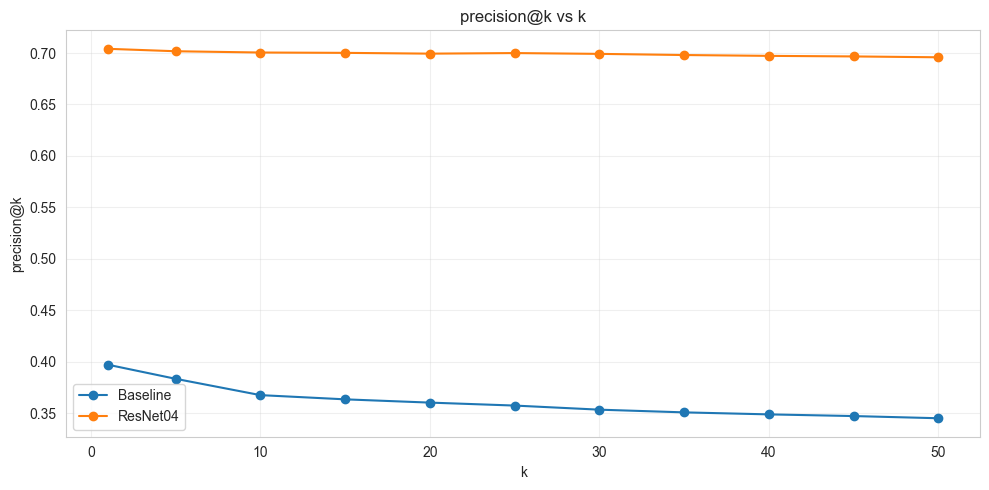

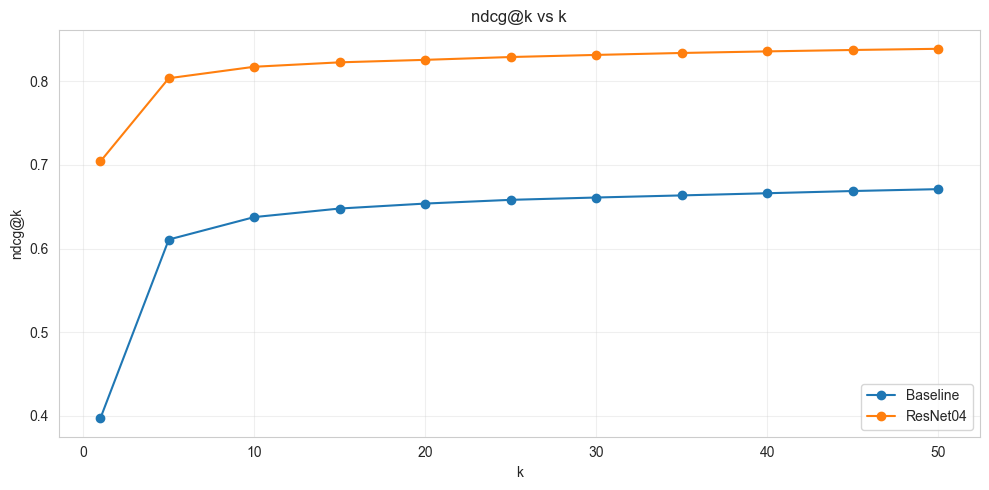

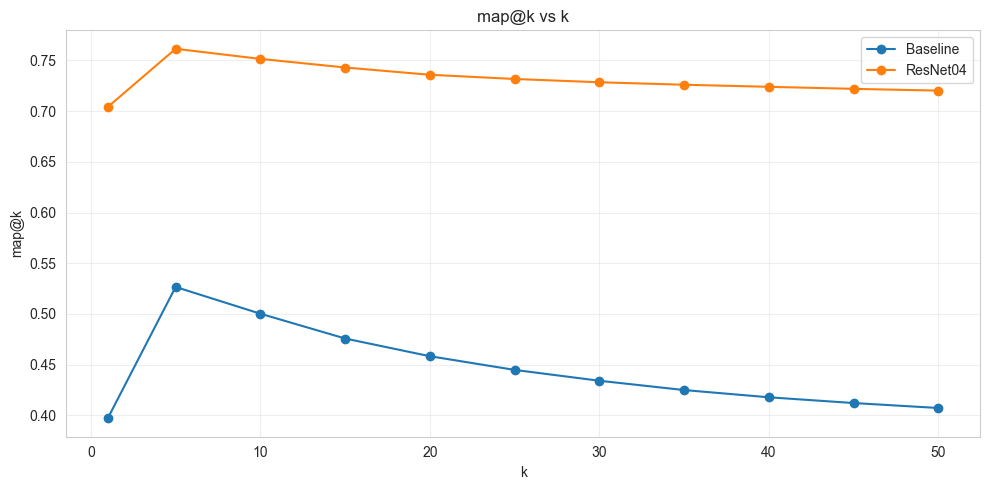

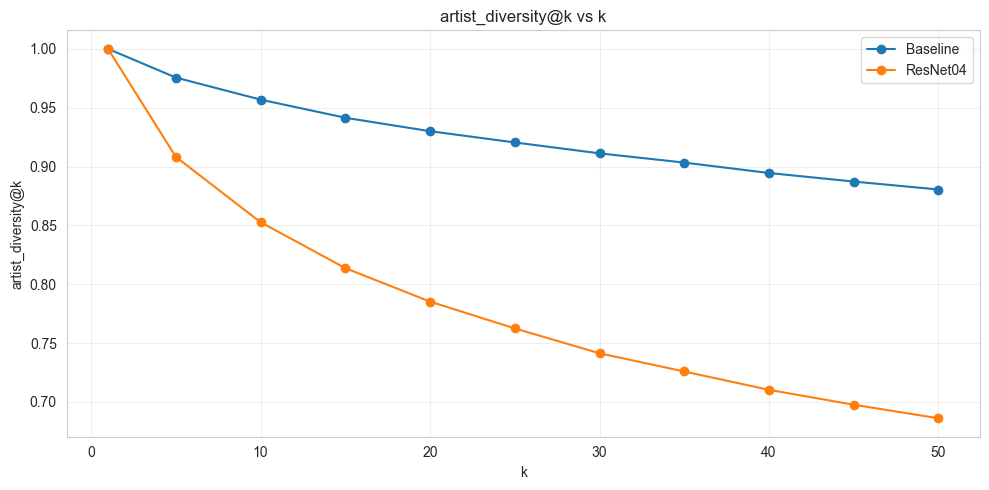

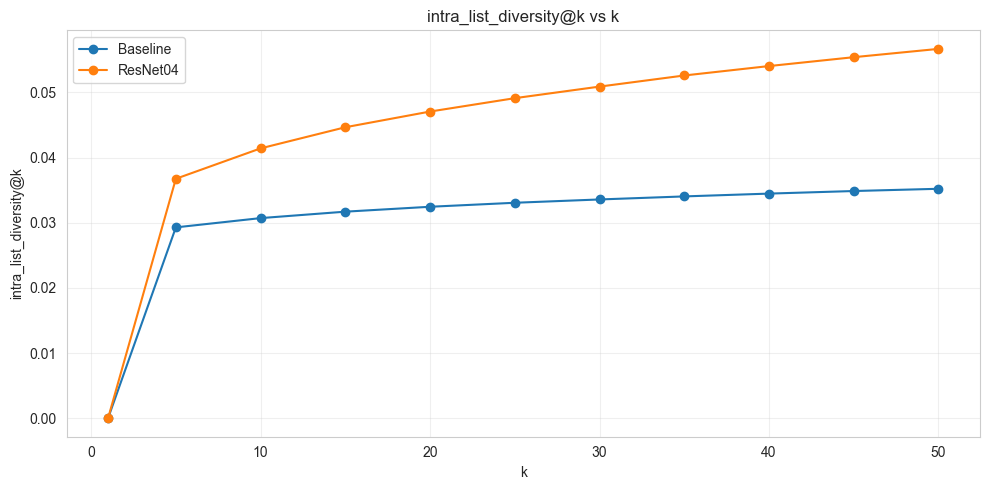

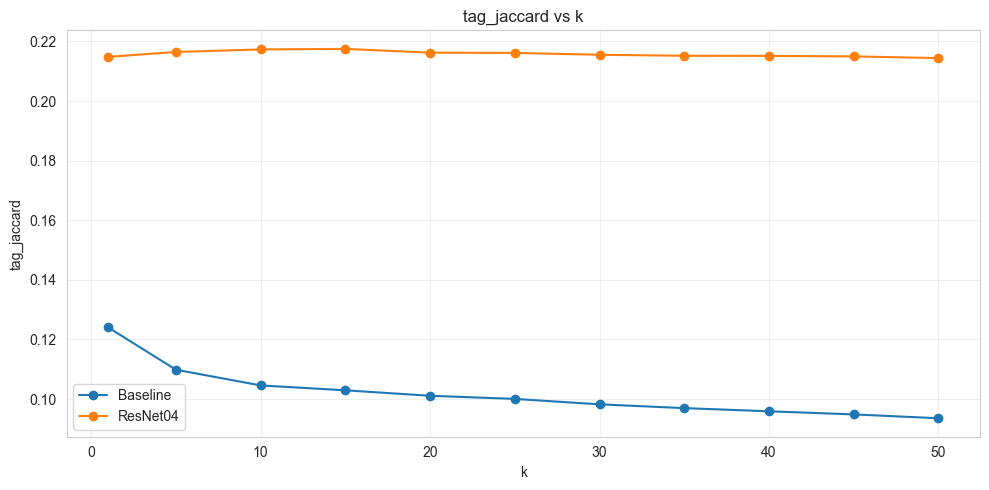

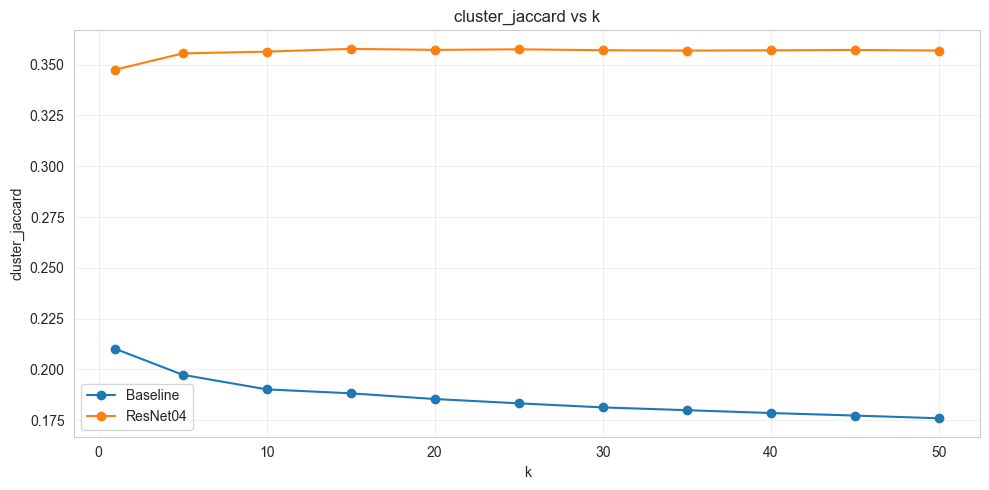

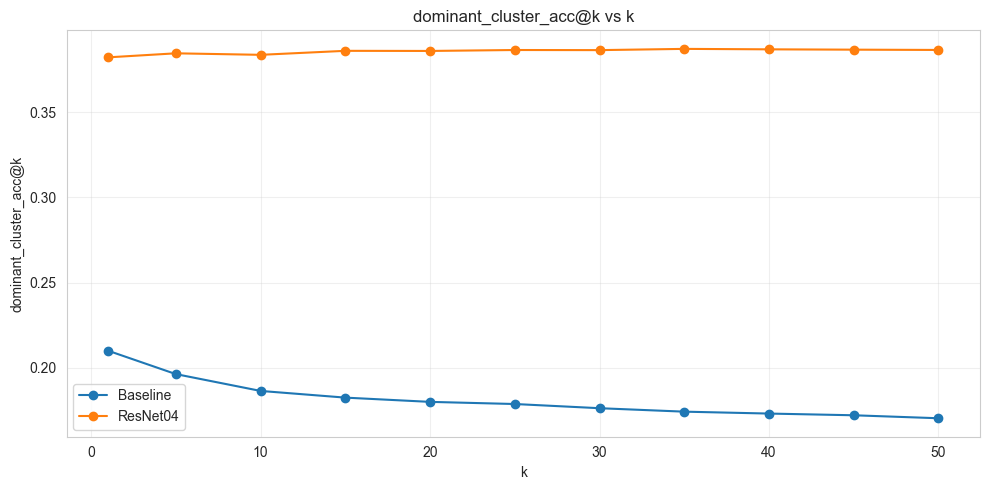

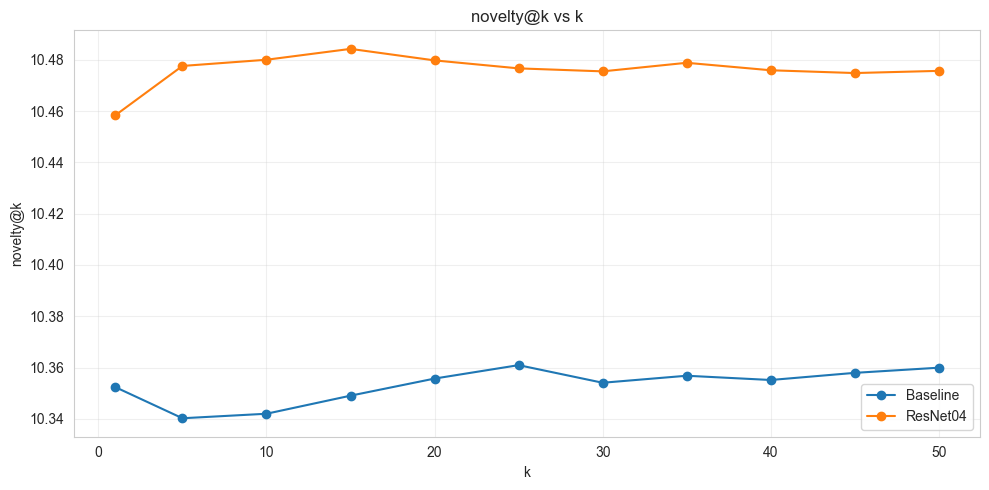

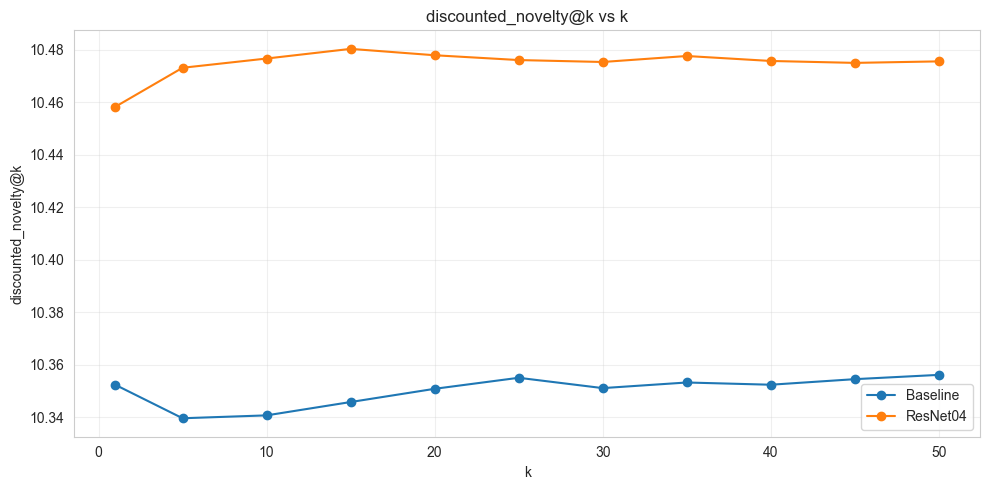

In [20]:
plot_metric_vs_k(all_results, "precision@k",             k_list)
plot_metric_vs_k(all_results, "ndcg@k",                  k_list)
plot_metric_vs_k(all_results, "map@k",                   k_list)
plot_metric_vs_k(all_results, "artist_diversity@k",      k_list)
plot_metric_vs_k(all_results, "intra_list_diversity@k",  k_list)
plot_metric_vs_k(all_results, "tag_jaccard",             k_list)
plot_metric_vs_k(all_results, "cluster_jaccard",         k_list)
plot_metric_vs_k(all_results, "dominant_cluster_acc@k",  k_list)
plot_metric_vs_k(all_results, "novelty@k",               k_list)
plot_metric_vs_k(all_results, "discounted_novelty@k",    k_list)

In [56]:
import json
import numpy as np
from pathlib import Path

# --- Config ---
N_RECS     = 5
SURVEY_DIR = Path("../survey")

# Specify your query tracks by spotify_id (must exist in full_df)
QUERY_SPOTIFY_IDS = [
    "7p4vHnYXkxlzvfePJVpcTr",
    "2Qkqr57m8U3b800Whaj9NL",
    "0dk90HgW9WPrArNabLOqjH",
    "3omCT6IN9w4wsCqhpglNVG",
    "1qaZx6y94LiMy2KdhHxRTy",
    "1AzvoRNvENhfB8w4CNPVIw",
    "3g97GeElmvxB0tFaREyHbm",
    "05lxXTWeG9ZZqEcHbJ0PW1",
    "0JVCIwkfHBWEkAysG1XsVw",
    "4NsPgRYUdHu2Q5JRNgXYU5",
    "650eiAftcdoorcciUfl61h",
    "03yQp1w8OBXq7KBXhzg0tB",
]

# Models to compare (must be full-catalog embeddings aligned with full_df)
survey_models = {
    "baseline": baseline_emb,
    "resnet04":  resnet04_emb,
    "resnet06": resnet06_emb,
    "resnet07":  resnet07_emb,
}

def track_meta(row):
    return {
        "spotify_id":  row["spotify_id"],
        "name":        row["name"],
        "artist":      row["artist"],
        "year":        int(row["year"]) if pd.notna(row.get("year")) else None,
        "preview_url": row.get("spotify_preview_url"),
    }

# Look up global indices in full_df
query_global_indices = []
for sid in QUERY_SPOTIFY_IDS:
    matches = full_df.index[full_df["spotify_id"] == sid].tolist()
    assert matches, f"spotify_id not found in full_df: {sid}"
    query_global_indices.append(matches[0])

# Generate recommendations
queries_data = []
for global_idx in query_global_indices:
    query_row = full_df.iloc[global_idx]
    entry = {"query": track_meta(query_row), "playlists": []}

    for model_name, full_model_emb in survey_models.items():
        rec_indices, _ = topk_cosine(
            full_model_emb, full_model_emb[global_idx],
            k=N_RECS, exclude_idx=global_idx,
        )
        entry["playlists"].append({
            "model":  model_name,
            "tracks": [track_meta(full_df.iloc[i]) for i in rec_indices],
        })

    queries_data.append(entry)

# Save
out_path = SURVEY_DIR / "survey_data.json"
with open(out_path, "w") as f:
    json.dump({"queries": queries_data}, f, indent=2)

print(f"Saved {len(queries_data)} queries → {out_path}")

Saved 12 queries → ..\survey\survey_data.json


In [18]:
survey_data = pd.read_json("../survey/results/Nick_20260317_231118.json")

In [21]:
survey_data["ratings"][0]

{'query_track': {'spotify_id': '7p4vHnYXkxlzvfePJVpcTr',
  'name': 'Feels Like Summer',
  'artist': 'Childish Gambino',
  'year': 2018,
  'preview_url': 'https://p.scdn.co/mp3-preview/047c2dc49290e69888f7a20e26aecf619be2aebd?cid=774b29d4f13844c495f206cafdad9c86'},
 'playlists': [{'label': 'A',
   'model': 'baseline',
   'track_ratings': ['👎 Bad', '👎 Bad', '👎 Bad', '👎 Bad', '👎 Bad']},
  {'label': 'B',
   'model': 'resnet06',
   'track_ratings': ['👍 Good', '😐 Neutral', '👎 Bad', '😐 Neutral', '👎 Bad']},
  {'label': 'C',
   'model': 'resnet07',
   'track_ratings': ['😐 Neutral',
    '👎 Bad',
    '😐 Neutral',
    '😐 Neutral',
    '👍 Good']},
  {'label': 'D',
   'model': 'resnet04',
   'track_ratings': ['👍 Good', '👍 Good', '😐 Neutral', '👍 Good', '😐 Neutral']}]}

In [22]:
import json
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("../survey/results")

RATING_SCORE = {"👍 Good": 1, "😐 Neutral": 0, "👎 Bad": -1}

def load_survey_results(results_dir):
    rows = []
    for subject_id, path in enumerate(sorted(results_dir.glob("*.json"))):
        with open(path) as f:
            data = json.load(f)

        for query_entry in data["ratings"]:
            query = query_entry["query_track"]
            for playlist in query_entry["playlists"]:
                model = playlist["model"]
                for t_idx, rating in enumerate(playlist["track_ratings"]):
                    rows.append({
                        "subject_id":    subject_id,
                        "query_name":    query["name"],
                        "query_artist":  query["artist"],
                        "query_id":      query["spotify_id"],
                        "model":         model,
                        "track_rank":    t_idx + 1,
                        "rating":        rating,
                        "score":         RATING_SCORE.get(rating, None),
                    })

    return pd.DataFrame(rows)

df = load_survey_results(RESULTS_DIR)
print(df.shape)
display(df.head(10))

(960, 8)


,subject_id,query_name,query_artist,query_id,model,track_rank,rating,score
0,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,1,👎 Bad,-1
1,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,2,👎 Bad,-1
2,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,3,👎 Bad,-1
3,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,4,👎 Bad,-1
4,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,5,👎 Bad,-1
5,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet06,1,👍 Good,1
6,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet06,2,😐 Neutral,0
7,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet06,3,👎 Bad,-1
8,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet06,4,😐 Neutral,0
9,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet06,5,😐 Neutral,0


In [23]:
df

,subject_id,query_name,query_artist,query_id,model,track_rank,rating,score
0,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,1,👎 Bad,-1
1,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,2,👎 Bad,-1
2,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,3,👎 Bad,-1
3,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,4,👎 Bad,-1
4,0,Feels Like Summer,Childish Gambino,7p4vHnYXkxlzvfePJVpcTr,resnet04,5,👎 Bad,-1
...,...,...,...,...,...,...,...,...
955,3,On the Sly,Metric,03yQp1w8OBXq7KBXhzg0tB,baseline,1,😐 Neutral,0
956,3,On the Sly,Metric,03yQp1w8OBXq7KBXhzg0tB,baseline,2,😐 Neutral,0
957,3,On the Sly,Metric,03yQp1w8OBXq7KBXhzg0tB,baseline,3,👎 Bad,-1
958,3,On the Sly,Metric,03yQp1w8OBXq7KBXhzg0tB,baseline,4,👎 Bad,-1


In [24]:
# Average score per model
display(df.groupby("model")["score"].agg(["mean", "count"]).round(3))

# Rating distribution per model
display(
    df.groupby(["model", "rating"])
      .size()
      .unstack(fill_value=0)
      .assign(total=lambda x: x.sum(axis=1))
)

,mean,count
model,,
baseline,-0.375,240
resnet04,0.275,240
resnet06,0.200,240
resnet07,0.117,240


rating,👍 Good,👎 Bad,😐 Neutral,total
model,,,,
baseline,38,128,74,240
resnet04,116,50,74,240
resnet06,109,61,70,240
resnet07,96,68,76,240


In [25]:
# Average score per subject per model
display(
    df.groupby(["subject_id", "model"])["score"]
      .mean()
      .unstack("model")
      .round(3)
)

model,baseline,resnet04,resnet06,resnet07
subject_id,,,,
0,-0.300,0.383,0.433,0.267
1,-0.417,0.317,0.150,0.167
2,-0.650,-0.033,-0.167,-0.267
3,-0.133,0.433,0.383,0.300
